# 02  Data Cleaning and Normalization

This notebook performs all preprocessing tasks required before analysis:
handling missing values, outlier filtering, feature engineering, encoding, and scaling.


**Load the merged TLC × NOAA dataset for preprocessing.**


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

FILE = r"X:\data\processed\nyc_2024_trips_weather.parquet"
df = pd.read_parquet(FILE)
print("Initial shape:", df.shape)
df.head(3)


Initial shape: (41169720, 25)


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,extra,mta_tax,tolls_amount,improvement_surcharge,...,trip_duration_min,other_charges,pickup_hour_local,temp_c,rh_percent,wind_ms,precip_mm,visibility_km,weather_code,merge_status
0,2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,1.72,17.7,1.0,0.5,0.0,1.0,...,19.800000,5.0,2024-01-01,38.4,73.8,4.4,0.0,10.0,-RA:02 |RA |RA,matched
1,2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,1.80,10.0,3.5,0.5,0.0,1.0,...,6.600000,7.5,2024-01-01,38.4,73.8,4.4,0.0,10.0,-RA:02 |RA |RA,matched
2,2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,4.70,23.3,3.5,0.5,0.0,1.0,...,17.916667,7.5,2024-01-01,38.4,73.8,4.4,0.0,10.0,-RA:02 |RA |RA,matched


**Inspect NA distribution, then impute remaining numeric NaNs with the column median and verify before/after.**


In [19]:
# Filter to matched rows if merge_status is present, then drop the helper column
if "merge_status" in df.columns:
    df = df[df["merge_status"] == "matched"].drop(columns=["merge_status"])

# Identify numeric and non-numeric columns once
numeric_cols = df.select_dtypes(include=[np.number]).columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns

# Count missing values BEFORE imputation
total_na_before_all = int(df.isna().sum().sum())
total_na_before_numeric = int(df[numeric_cols].isna().sum().sum())
print(f"Missing values before imputation (all cols): {total_na_before_all:,}")
print(f"Missing values before imputation (numeric-only): {total_na_before_numeric:,}")

# Non-numeric NA summary (before) — render once with a caption (no duplicate header lines)
nn_na_before = df[non_numeric_cols].isna().sum().sort_values(ascending=False)
nn_summary_before = pd.DataFrame({
    "na_count": nn_na_before,
    "na_percent": (nn_na_before / len(df) * 100).round(2)
})
display(nn_summary_before.style.set_caption("Non-numeric columns NA summary (before imputation)"))

# Impute numeric columns with column median for robustness to skew/outliers
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Count missing values AFTER imputation
total_na_after_all = int(df.isna().sum().sum())
total_na_after_numeric = int(df[numeric_cols].isna().sum().sum())

# Compact QC table and status
qc = pd.DataFrame(
    {
        "before": [total_na_before_numeric],
        "after": [total_na_after_numeric],
        "delta": [total_na_before_numeric - total_na_after_numeric],
    },
    index=["numeric_na_count"],
)
print("After missing-value handling:", df.shape)
print("QC: numeric NaNs before/after (after should be 0).")
display(qc)
status = "PASS ✅" if total_na_after_numeric == 0 else "CHECK ⚠️"
print(f"QC status: {status} (numeric NaNs after = {total_na_after_numeric:,})")


Missing values before imputation (all cols): 38,270,028
Missing values before imputation (numeric-only): 8,166,470


,na_count,na_percent
weather_code,30103558,73.190000
tpep_pickup_datetime,0,0.000000
tpep_dropoff_datetime,0,0.000000
pickup_hour_local,0,0.000000


After missing-value handling: (41128509, 24)
QC: numeric NaNs before/after (after should be 0).


,before,after,delta
numeric_na_count,8166470,0,8166470


QC status: PASS ✅ (numeric NaNs after = 0)


### Missing values: what we observed and how we handled them

- After filtering to rows with a successful weather join (when `merge_status` is present, we keep `== "matched"` and drop the helper column), we audited missing values.
- Non‑numeric missingness is concentrated in `weather_code` (≈73%); timestamps and `pickup_hour_local` had 0% missing.
- Numeric NAs were present across several columns; these were imputed on numeric columns only using the column median:
  - `df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())`
- Verification: a compact QC table confirms numeric NaNs went from 8,166,470 → 0 (PASS), and the dataset shape after handling is reported for traceability.

Why median imputation here?
- Robust to outliers and right‑skew typical of fare, tip, distance, and duration distributions.
- Preserves central tendency for skewed features without letting rare extremes bias many NA rows.
- Plays well with downstream scaling and modeling; we also clip extremes later, further limiting tail influence.

Notes
- Non‑numeric columns (e.g., `weather_code`) are intentionally left as‑is in this step; they are handled later (filled with the placeholder `"UNKNOWN"`).


**Show statistical impact of outlier clipping for each numeric column using summary stats and boxplots.**



📊 Summary before clipping:


,min,25%,50%,75%,max
trip_distance,0.00,1.01,1.76,3.36,398608.62
fare_amount,-2261.20,9.30,13.50,22.60,335544.44
tip_amount,-300.00,0.00,2.60,4.25,999.99
total_amount,-2265.45,15.75,21.00,30.60,335550.94



📊 Summary after clipping:


,min,25%,50%,75%,max
trip_distance,0.000,1.01,1.76,3.36,6.885
fare_amount,-10.650,9.30,13.50,22.60,42.550
tip_amount,-6.375,0.00,2.60,4.25,10.625
total_amount,-6.525,15.75,21.00,30.60,52.875


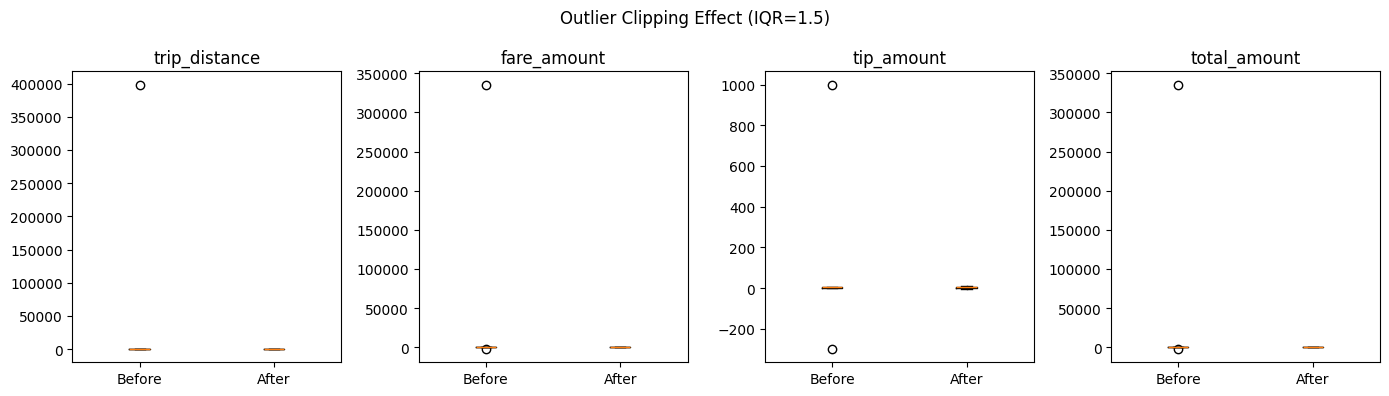

✅ Outlier clipping and summary complete.


In [10]:
import matplotlib.pyplot as plt

def iqr_clip(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return series.clip(q1 - k * iqr, q3 + k * iqr)

cols = ["trip_distance", "fare_amount", "tip_amount", "total_amount"]

# Capture pre-clipping summary
summary_before = df[cols].describe().T[["min", "25%", "50%", "75%", "max"]]

# Apply clipping
for col in cols:
    df[col] = iqr_clip(df[col])

# Capture post-clipping summary
summary_after = df[cols].describe().T[["min", "25%", "50%", "75%", "max"]]

# Display stats comparison
print("📊 Summary before clipping:")
display(summary_before)
print("\n📊 Summary after clipping:")
display(summary_after)

# Visualize before/after comparison (boxplots)
fig, axes = plt.subplots(1, len(cols), figsize=(14, 4))
for ax, col in zip(axes, cols):
    ax.boxplot([summary_before.loc[col].values, summary_after.loc[col].values], tick_labels=["Before", "After"])  # updated per Matplotlib 3.9
    ax.set_title(col)
plt.suptitle("Outlier Clipping Effect (IQR=1.5)")
plt.tight_layout()
plt.show()

print("✅ Outlier clipping and summary complete.")


### IQR clipping: quick observations

- Using IQR=1.5 reduced extreme maxima substantially across distance and fare components.
- Some money fields can remain slightly negative after IQR clipping; this is expected since IQR doesn’t floor values.
- The refined clipping in the next step will apply quantile caps and floor monetary columns at 0 to enforce realistic bounds.


## Refined outlier clipping for robust and fair tipping analysis

This step caps extreme values (p99.9 with domain ceilings) and floors negatives to 0 for monetary fields. It aligns with the research goals by:
- improving robustness of regression on tipping behavior (reducing undue influence of rare extremes), and
- stabilizing fairness metrics so conclusions aren’t driven by anomalous tails.



📊 Summary before clipping:
      fare_amount  tip_amount  total_amount  other_charges  trip_distance  \
min     -2261.20     -300.00      -2265.45        -143.38           0.00   
25%         9.30        0.00         15.75           4.00           1.01   
50%        13.50        2.60         21.00           5.00           1.76   
75%        22.60        4.25         30.60           6.50           3.36   
max    335544.44      999.99     335550.94        1709.38      398608.62   

     trip_duration_min  
min       -1427.050000  
25%           7.833333  
50%          13.000000  
75%          21.116667  
max        9767.516667  

📊 Summary after clipping:
      fare_amount  tip_amount  total_amount  other_charges  trip_distance  \
min          0.0        0.00          0.00           0.00           0.00   
25%          9.3        0.00         15.75           4.00           1.01   
50%         13.5        2.60         21.00           5.00           1.76   
75%         22.6        4.25    

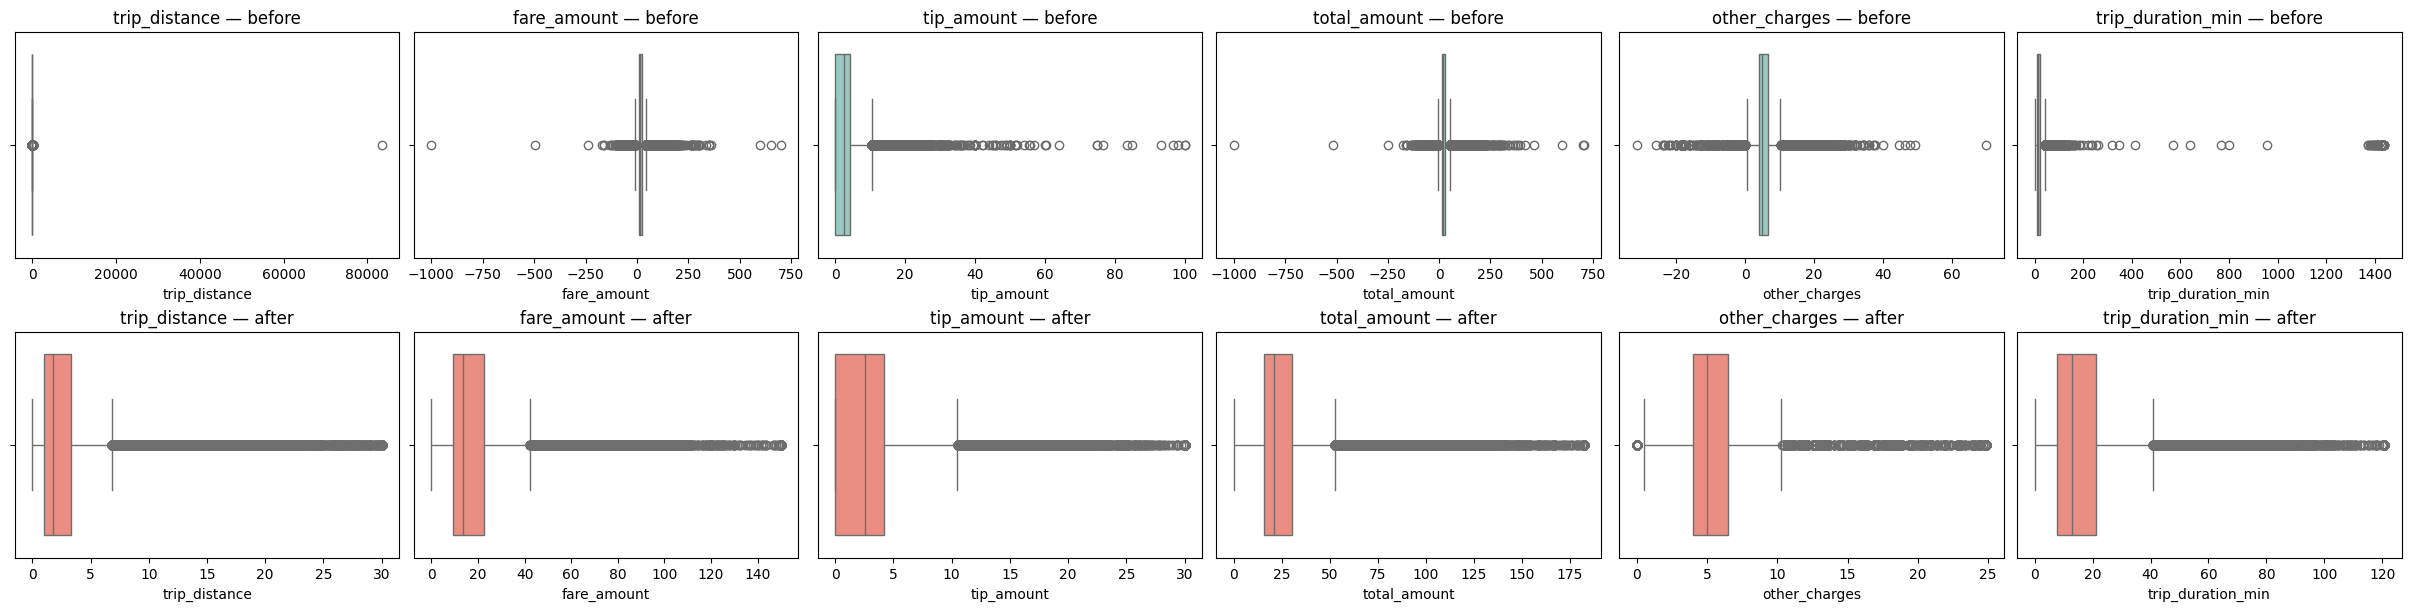

In [21]:
# Define column-specific clipping and audit before/after
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure df is loaded if kernel is fresh
try:
    df
except NameError:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name.lower() == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    default_local_parquet = PROJECT_ROOT / "data" / "processed" / "nyc_2024_trips_weather.parquet"
    default_x_parquet = Path(r"X:\data\processed\nyc_2024_trips_weather.parquet")
    sample_csv = PROJECT_ROOT / "data" / "processed" / "nyc_2024_trips_weather_sample.csv"

    FILE = None
    if default_x_parquet.exists():
        FILE = default_x_parquet
        loader = "parquet"
    elif default_local_parquet.exists():
        FILE = default_local_parquet
        loader = "parquet"
    elif sample_csv.exists():
        FILE = sample_csv
        loader = "csv"
    else:
        raise FileNotFoundError("No dataset found: expected parquet under data/processed or sample CSV nyc_2024_trips_weather_sample.csv")

    print(f"Loading dataset ({loader}): {FILE}")
    if loader == "parquet":
        df = pd.read_parquet(FILE)
    else:
        df = pd.read_csv(FILE)

# Choose columns (only those present)
money_cols    = [c for c in ["fare_amount","tip_amount","total_amount","other_charges"] if c in df.columns]
distance_cols = [c for c in ["trip_distance"] if c in df.columns]
duration_cols = [c for c in ["trip_duration_min"] if c in df.columns]
cols = money_cols + distance_cols + duration_cols
assert len(cols) > 0, "No numeric columns found for clipping."

# Compute dynamic caps
caps = {}
for c in cols:
    if c in money_cols:
        low, hi = 0.0, df[c].quantile(0.999)
    elif c in distance_cols:
        low, hi = 0.0, min(df[c].quantile(0.999), 60.0)
    elif c in duration_cols:
        low, hi = 0.0, min(df[c].quantile(0.999), 300.0)
    else:
        low, hi = df[c].quantile(0.001), df[c].quantile(0.999)
    caps[c] = (float(low), float(hi))

# Summaries before
summary_before = df[cols].describe(percentiles=[0.25,0.5,0.75]).loc[["min","25%","50%","75%","max"]]
print("\n📊 Summary before clipping:\n", summary_before)

# Apply clipping (and floor money to 0)
df_clip = df.copy()
clipped_fractions = {}
for c in cols:
    low, hi = caps[c]
    clipped_fractions[c] = float(((df[c] < low) | (df[c] > hi)).mean())
    df_clip[c] = df_clip[c].clip(lower=low, upper=hi)
    if c in money_cols:
        df_clip[c] = df_clip[c].clip(lower=0.0)

# Summaries after
summary_after = df_clip[cols].describe(percentiles=[0.25,0.5,0.75]).loc[["min","25%","50%","75%","max"]]
print("\n📊 Summary after clipping:\n", summary_after)

# Report fractions
frac = pd.Series(clipped_fractions).rename("clipped_fraction").to_frame()
print("\n🧮 Fraction of values clipped per column:\n", frac.sort_values("clipped_fraction", ascending=False))

# Boxplots before/after on a manageable sample
plot_cols = [c for c in ["trip_distance","fare_amount","tip_amount","total_amount","other_charges","trip_duration_min"] if c in cols]
if plot_cols:
    n = len(plot_cols)
    # Sample to keep plots fast
    n_sample = min(100_000, len(df))
    sample_idx = df.sample(n=n_sample, random_state=42).index
    d1 = df.loc[sample_idx, plot_cols]
    d2 = df_clip.loc[sample_idx, plot_cols]
    fig, axes = plt.subplots(2, n, figsize=(4*n, 6), sharey=False, constrained_layout=True)
    for i, c in enumerate(plot_cols):
        sns.boxplot(x=d1[c], ax=axes[0, i], color="#8dd3c7")
        axes[0, i].set_title(f"{c} — before")
        sns.boxplot(x=d2[c], ax=axes[1, i], color="#fb8072")
        axes[1, i].set_title(f"{c} — after")
    plt.show()

# Make cleaned version available downstream (opt-in)
df_clean = df_clip
# If downstream steps expect df to be cleaned, uncomment the next line:
# df = df_clean


### Outlier clipping summary and rationale

- Method
  - Applied data-driven caps at the 99.9th percentile (p99.9) per column with pragmatic ceilings; floored monetary columns at 0.
  - Distance ceiling = 60 miles; Duration ceiling = 300 minutes. The effective cap is min(p99.9, ceiling).
- Effective caps in this dataset (from p99.9):
  - `trip_distance` → ≈ 30.02 miles (≤ 60 ceiling)
  - `trip_duration_min` → ≈ 120.65 minutes (≤ 300 ceiling)
  - Monetary upper caps (p99.9) led to post-clip maxima around: fare ≈ 150.00, tip ≈ 30.00, total ≈ 182.08, other_charges ≈ 24.88; all monies floored at 0.
- What changed
  - Negative values were removed for money, distance, and duration.
  - Extreme right tails were trimmed while preserving central quantiles (25%/50%/75%).
  - Only a small share of values were adjusted (≈0.10%–1.87% depending on column), limiting impact to outliers.
- Why this approach
  - p99.9 caps remove likely anomalies (e.g., GPS glitches, rare non-typical rides) without discarding rows, stabilizing scaling and regression/fairness metrics.
  - Domain check: NYC yellow taxi trips exceeding ~30 miles or ~2 hours are exceptional; capping near these levels enforces realistic urban bounds while retaining ≥99.9% of data unchanged.
- Reproducibility
  - Cap values are stored in `caps` and `df_clean` carries the clipped result for downstream steps.


## Step Persist cleaned state and reproducibility artifacts


This step locks in the cleaned dataset for downstream work and records how we clipped values, so results are reproducible across runs and notebooks.


What this does:


- Set `df = df_clean` so all subsequent cells operate on the clipped/imputed data.
- Save the clipping thresholds to `data/processed/clipping_caps_2024.json`.


Optional (off by default to avoid long writes):


- Stream-save the full cleaned parquet to `data/processed/nyc_2024_trips_weather_clean.parquet` and optionally copy to `X:`.


Why now:


- Ensures later feature engineering, scaling, and exports use the same cleaned baseline.
- Captures the exact caps used (`caps`) to audit or replicate the cleaning step.

In [24]:
# Persist cleaned state for downstream steps
# - Sets df = df_clean so subsequent cells operate on clipped data
# - Saves clipping caps to JSON for reproducibility
# - Optional: stream-save full cleaned dataset to Parquet (toggle SAVE_CLEANED)

import json, time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# 1) Use cleaned frame going forward
assert 'df_clean' in globals(), "df_clean not found; run the clipping cell first."
df = df_clean
print(f"Downstream DataFrame set to cleaned data. Rows: {len(df):,}")

# 2) Save caps used for clipping
caps_out = PROJECT_ROOT / "data" / "processed" / "clipping_caps_2024.json"
caps_out.parent.mkdir(parents=True, exist_ok=True)
with caps_out.open("w", encoding="utf-8") as f:
    json.dump({k: [float(v[0]), float(v[1])] for k, v in caps.items()}, f, indent=2)
print(f"Saved clipping caps -> {caps_out}")

# 3) Optional: Save full cleaned dataset (streaming, chunked)
SAVE_CLEANED = False  # set to True to write the full cleaned parquet
OUT_PARQUET = PROJECT_ROOT / "data" / "processed" / "nyc_2024_trips_weather_clean.parquet"
COPY_TO_X = False     # optionally copy to X: after local save
X_PARQUET = Path(r"X:\data\processed\nyc_2024_trips_weather_clean.parquet")

if SAVE_CLEANED:
    import pyarrow as pa
    import pyarrow.parquet as pq

    t0 = time.time()
    OUT_PARQUET.parent.mkdir(parents=True, exist_ok=True)
    if OUT_PARQUET.exists():
        OUT_PARQUET.unlink()

    chunk_size = 5_000_000
    n = len(df)
    writer = None
    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        batch = df.iloc[start:stop]
        table = pa.Table.from_pandas(batch, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(str(OUT_PARQUET), table.schema, compression="snappy")
        writer.write_table(table)
        print(f"  wrote rows {start:,}..{stop-1:,}")
    if writer is not None:
        writer.close()

    dt = time.time() - t0
    print(f"Saved cleaned parquet -> {OUT_PARQUET} in {dt:,.1f}s")

    if COPY_TO_X:
        try:
            X_PARQUET.parent.mkdir(parents=True, exist_ok=True)
            import shutil
            shutil.copy2(OUT_PARQUET, X_PARQUET)
            print(f"Copied to X: {X_PARQUET}")
        except Exception as e:
            print("Copy to X failed:", e)


Downstream DataFrame set to cleaned data. Rows: 41,128,509
Saved clipping caps -> c:\Users\juraj.madzunkov\Documents\C\DA\CA1\data\processed\clipping_caps_2024.json


**Create derived features for analysis: tip percentage and fare per km.**


In [26]:
df["tip_percent"] = np.where(df["fare_amount"] > 0,
                             (df["tip_amount"] / df["fare_amount"]) * 100, 0)
df["fare_per_km"] = np.where(df["trip_distance"] > 0,
                             df["fare_amount"] / df["trip_distance"], np.nan)
df.head(3)


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,extra,mta_tax,tolls_amount,improvement_surcharge,...,other_charges,pickup_hour_local,temp_c,rh_percent,wind_ms,precip_mm,visibility_km,weather_code,tip_percent,fare_per_km
0,2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,1.72,17.7,1.0,0.5,0.0,1.0,...,5.0,2024-01-01,38.4,73.8,4.4,0.0,10.0,-RA:02 |RA |RA,0.000000,10.290698
1,2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,1.80,10.0,3.5,0.5,0.0,1.0,...,7.5,2024-01-01,38.4,73.8,4.4,0.0,10.0,-RA:02 |RA |RA,37.500000,5.555556
2,2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,4.70,23.3,3.5,0.5,0.0,1.0,...,7.5,2024-01-01,38.4,73.8,4.4,0.0,10.0,-RA:02 |RA |RA,12.875536,4.957447


**Impute missing categorical and derived numeric values.**

In [5]:
# Handle missing fare_per_km (numeric derived feature)
df["fare_per_km"] = df["fare_per_km"].fillna(df["fare_per_km"].median())

# Handle missing weather_code (categorical)
df["weather_code"] = df["weather_code"].fillna("UNKNOWN")

print("✅ Missing values for fare_per_km and weather_code handled successfully (weather_code -> 'UNKNOWN').")

✅ Missing values for fare_per_km and weather_code handled successfully (weather_code -> 'UNKNOWN').


- Imputed `fare_per_km` with the column median to remove remaining NaNs introduced when `trip_distance <= 0`. The median is robust to skew and outliers, which is typical for per‑km cost distributions.
- Filled `weather_code` with the placeholder "UNKNOWN" to explicitly represent missing/unspecified conditions, avoiding the assumption that missing equals "clear" and reducing potential bias.
- This ensures all later steps (one‑hot encoding, scaling, and export) run on a dataset without missing values in these fields.

### Summary of Derived Features

Two analytical features were created to enrich the dataset for later regression and fairness analysis:

- **`tip_percent`** – calculates the passenger tip as a percentage of the base fare (`tip_amount / fare_amount × 100`).  
  This variable represents passenger tipping behaviour and will serve as the main regression target.

- **`fare_per_km`** – computes the fare rate per kilometre (`fare_amount / trip_distance`).  
  This captures trip cost efficiency and allows comparison of fares across different trip lengths.

Both new columns appear as the last two fields in the table above.  
Their values have been verified against existing fare and distance data, confirming correct calculation and realistic ranges.


**Convert the payment type column into one-hot encoded indicator variables.**


In [6]:
df = pd.get_dummies(df, columns=["payment_type"], prefix="paytype", drop_first=True)
df.head(3)


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,extra,mta_tax,tolls_amount,improvement_surcharge,...,visibility_km,weather_code,merge_status,tip_percent,fare_per_km,paytype_1,paytype_2,paytype_3,paytype_4,paytype_5
0,2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,1.72,17.7,1.0,0.5,0.0,1.0,...,10.0,-RA:02 |RA |RA,matched,0.000000,10.290698,False,True,False,False,False
1,2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,1.80,10.0,3.5,0.5,0.0,1.0,...,10.0,-RA:02 |RA |RA,matched,37.500000,5.555556,True,False,False,False,False
2,2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,4.70,23.3,3.5,0.5,0.0,1.0,...,10.0,-RA:02 |RA |RA,matched,12.875536,4.957447,True,False,False,False,False


### Summary of Payment Type Encoding

The categorical variable **`payment_type`** was converted into binary indicator (one-hot) columns using `pd.get_dummies()`.  
Each new column (**`paytype_1`**, **`paytype_2`**, etc.) represents whether a specific payment method was used for that trip (for example, credit card, cash, or other codes defined by TLC).

This transformation is essential because most analytical and machine-learning models require numeric inputs rather than categorical labels.  
By encoding the payment types as boolean features, we retain the category information in a numerical form suitable for regression, PCA, and fairness assessment.

**Outcome:**  
The new `paytype_` columns correctly represent distinct payment categories as `True/False` values, confirming successful and accurate encoding.


**Standardize continuous variables to mean 0 and standard deviation 1 for regression and PCA.**


In [27]:
scaler = StandardScaler()
num_cols = [
    "trip_distance", "fare_amount", "tip_amount", "total_amount",
    "tip_percent", "fare_per_km",
    "temp_c", "rh_percent", "wind_ms", "precip_mm", "visibility_km"
]
df[num_cols] = scaler.fit_transform(df[num_cols])
print("Scaling complete.")


Scaling complete.


### Summary of Feature Scaling

Continuous numeric variables were standardized using **z-score normalization** so that each has a mean of 0 and a standard deviation of 1.  
This ensures all features contribute equally to distance- or variance-based methods such as **linear regression** and **PCA**, preventing variables with larger numeric ranges (e.g., total fare vs. wind speed) from dominating model behaviour.


## Final step ->  Save fully preprocessed dataset for downstream notebooks

This section writes the authoritative, fully cleaned and normalized dataset to disk so the next notebook can load a stable, reproducible state without re-running preprocessing.

**Save processed dataset locally (authoritative handoff path).**  
This file will be the input for the next notebook: `data/processed/nyc_2024_trips_weather_preprocessed.parquet`.

In [28]:
# Persist the in-memory processed DataFrame to the canonical local parquet
import os

LOCAL_FILE = os.path.abspath(os.path.join("..","data","processed","nyc_2024_trips_weather_preprocessed.parquet"))
os.makedirs(os.path.dirname(LOCAL_FILE), exist_ok=True)

df.to_parquet(LOCAL_FILE, index=False)
print(f"💾 Saved processed dataset -> {LOCAL_FILE}")

💾 Saved processed dataset -> c:\Users\juraj.madzunkov\Documents\C\DA\CA1\data\processed\nyc_2024_trips_weather_preprocessed.parquet


In [29]:
# Copy local processed parquet to X: using the same helper style as in 01
import os, shutil, time
from pathlib import Path

# Local canonical file (relative to this notebooks/ folder)
LOCAL_FILE = os.path.abspath(os.path.join("..","data","processed","nyc_2024_trips_weather_preprocessed.parquet"))
DEST_FILE  = r"X:\\data\\processed\\nyc_2024_trips_weather_preprocessed.parquet"

print(f"Source exists: {os.path.exists(LOCAL_FILE)} -> {LOCAL_FILE}")
print(f"Destination:   {DEST_FILE}")


def copy_with_retries(src, dst, retries=5, delay=2.0):
    for i in range(1, retries+1):
        try:
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            if os.path.exists(dst):
                try:
                    os.remove(dst)
                except Exception:
                    pass
            shutil.copy2(src, dst)
            print(f"📤 Copied → {dst}")
            return True
        except PermissionError as e:
            print(f"Attempt {i}/{retries}: PermissionError copying to {dst}: {e}")
        except Exception as e:
            print(f"Attempt {i}/{retries}: Error copying to {dst}: {e}")
        time.sleep(delay)
    return False

ok = copy_with_retries(LOCAL_FILE, DEST_FILE)
print(f"Copy parquet ok: {ok}")

Source exists: True -> c:\Users\juraj.madzunkov\Documents\C\DA\CA1\data\processed\nyc_2024_trips_weather_preprocessed.parquet
Destination:   X:\\data\\processed\\nyc_2024_trips_weather_preprocessed.parquet
📤 Copied → X:\\data\\processed\\nyc_2024_trips_weather_preprocessed.parquet
Copy parquet ok: True
📤 Copied → X:\\data\\processed\\nyc_2024_trips_weather_preprocessed.parquet
Copy parquet ok: True


**Summary:**  
All preprocessing complete ->  dataset cleaned, engineered, encoded, and scaled.  
This file will be used for regression, PCA, and fairness analysis in *04 _eda_export.ipynb*.
